# AdventureWorks Sales Forecasting
## Time Series Analysis Using Facebook Prophet

**Dataset:** Microsoft AdventureWorks Sample Data  
**Tools:** Python, Prophet, pandas, matplotlib  
**Date:** 2026


## Executive Summary

**Key findings from 12 month forecast (July 2020 - June 2021):**

- **Total Revenue** projected at ~$61M - continued growth with strong Q4 seasonality. Model accuracy: 31.4% MAPE
- **Internet channel** forecast to outgrow Reseller in percentage terms - strategic margin implications given Internet operates at ~41% profit margin vs Reseller's ~0.6%
- **Reseller channel** shows continued seasonality but limited structural growth - 68.7% MAPE reflects high monthly volatility from large individual orders
- **Bikes category** remains dominant at ~86% of total revenue - concentration risk worth monitoring
- **COVID-19 caveat** - training data overlaps the pandemic period (March 2020 onward). The Internet acceleration may be partially pandemic-driven rather than a permanent structural shift. Forecasts should be treated as directional indicators



## 1. Introduction and Business Problem

AdventureWorks Cycles operates across two distinct sales channels - a Reseller network and a direct Internet channel - spanning 11 territories across North America, Europe, and the Pacific.

This notebook answers a straightforward but commercially important question:

> *Given four years of historical sales data, what does the next 12 months look like for revenue across channels and product categories?*

Understanding forward-looking revenue trends allows the business to:
- Plan inventory and resource allocation ahead of demand peaks
- Identify whether the rapid Internet channel growth is expected to continue
- Spot early warning signs of declining product categories
- Compare channel trajectories to inform strategic investment decisions

### What stood out before modelling

A few things shaped the modelling approach during initial exploration:

1. **Razor-thin reseller margins** - the Reseller channel operates at ~0.6% profit margin vs ~41% for Internet. This makes the channel mix story more important than the absolute revenue numbers.

2. **Clear yearly seasonality** - revenue spikes consistently in Q4 across both channels, driven by the Bikes category. This made Prophet a natural choice over ARIMA since it handles yearly seasonality automatically without manual parameter tuning.

3. **Internet channel acceleration** - from early FY2020 the Internet channel shows a noticeably steeper growth trajectory. This structural shift required metric-specific model tuning - more on this in Section 9.

4. **COVID-19 overlap** - the final year of training data (FY2020, July 2019 - June 2020) partially overlaps the pandemic period. This has measurable effects on both channels that are worth understanding before interpreting the forecasts.

5. **Limited training data** - only 36 monthly observations are available. This is on the lower end for time series modelling and the accuracy metrics reflect that honestly throughout.

### Modelling approach

- **Model:** Facebook Prophet - chosen for automatic seasonality handling and interpretable confidence intervals
- **Granularity:** Monthly aggregation
- **Horizon:** 12 months beyond June 2020
- **Growth:** Linear with additive seasonality
- **Validation:** Cross-validation using Prophet's sliding window approach
- **Metrics reported:** MAPE and MAE - both are shown because MAPE alone can be misleading when actual values are near zero


## Recommendations

These recommendations are drawn from both the forecasting analysis and the broader dashboard insights across all five pages of the AdventureWorks Power BI report.

---

### 1. Prioritise Internet channel investment
The Internet channel is forecast to grow faster than Reseller and operates at dramatically higher margins (~41% vs ~0.6%). Every dollar of revenue shifted from Reseller to Internet has an outsized impact on total profitability. Digital marketing, customer acquisition, and online product range expansion should be prioritised.

### 2. Conduct a Reseller profitability review
The razor-thin Reseller margin isn't a forecasting artefact it's consistent across the entire four year history. Options worth evaluating:
- Renegotiate pricing with low-margin resellers
- Focus growth efforts on Specialty Bike Shops which show better margin profiles than Warehouse resellers
- Strategically exit relationships with chronically unprofitable resellers

### 3. Address Bikes category concentration risk
Bikes drives ~86% of revenue and essentially all seasonality. This concentration creates vulnerability to supply disruptions, demand shifts, or competitive pressure in a single category. Cross-sell and bundling strategies to grow Accessories and Components revenue would improve resilience.

### 4. Build H1 demand generation programmes
Q4 seasonality is reliable and strong but it creates structurally lower revenue in the first half of each fiscal year (H1 - July to December for AdventureWorks). Targeted promotions, financing offers, or corporate sales programmes aimed at Q1 and Q2 would smooth the revenue curve and reduce cash flow pressure in the quieter first half of the year.

### 5. Revisit forecasts with additional data
The models were trained on 36 monthly observations on the lower end for time series forecasting. With each additional year of data the seasonal patterns stabilise and accuracy improves significantly. These forecasts should be treated as directional planning tools rather than precise targets until more history is available.

## 2. Setup and Configuration

In [40]:
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

warnings.filterwarnings("ignore")

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

# ── Configuration constants ───────────────────────────────────
FILE_PATH = "AdventureWorks_Sales_Cleaned.xlsx"
FORECAST_PERIODS = 12
FORECAST_FREQ = "MS"
CONFIDENCE_INTERVAL = 0.95
CHANGEPOINT_PRIOR = 0.05
CHANGEPOINT_PRIOR_INTERNET = 0.15  # higher - captures FY2020 acceleration
MIN_DATA_POINTS = 12
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Colour palette - matches Power BI dashboard theme
COLOUR_ACTUAL = "#1F4E79"
COLOUR_FORECAST = "#2563eb"
COLOUR_CI = "#2563eb"

print("Setup complete")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Setup complete
Output directory: C:\Users\he145100\outputs


## 3. Data Loading

The cleaned AdventureWorks Excel workbook contains 7 sheets. For forecasting we only need three:
- **Sales** - 121,253 transaction rows
- **Sales Order** - channel identifier (Reseller vs Internet)
- **Product_data** - product category for category-level forecasts

In [41]:
def load_data(file_path: str) -> dict[str, pd.DataFrame]:
    """
    Loads relevant sheets from the cleaned AdventureWorks workbook.

    Parameters
    ----------
    file_path : str
        Path to the cleaned Excel workbook
    Returns
    -------
    dict[str, pd.DataFrame]
        Dictionary of dataframes keyed by short name
    """
    sheets = {
        "sales": "Sales",
        "sales_order": "Sales Order",
        "product": "Product",
    }

    data = {}
    for key, sheet_name in sheets.items():
        data[key] = pd.read_excel(file_path, sheet_name=sheet_name)
        print(f"  Loaded {sheet_name:<25} {len(data[key]):>7,} rows")

    return data

print("Loading data...")
data = load_data(FILE_PATH)
print("\n All sheets loaded successfully")

Loading data...
  Loaded Sales                     121,253 rows
  Loaded Sales Order               121,253 rows
  Loaded Product                       397 rows

 All sheets loaded successfully


## 4. Data Preparation

A few things need to happen before we can model:

1. **Date conversion** - OrderDateKey is stored as an integer (YYYYMMDD format). We convert it to a proper datetime and then aggregate to month start for time series consistency.

2. **Channel merge** - The channel field (Reseller / Internet) lives in a separate Sales Order table. We join it onto the main sales table.

3. **Category merge** - Product category comes from the Product table. We need this for category-level forecasts.

One thing worth noting - aggregating to monthly rather than daily is a deliberate choice. Daily data with 36 months would give us 1,095 data points but most would be sparse and noisy. Monthly aggregation gives us 36 clean data points that Prophet can work with more reliably.

In [42]:
def prepare_sales_data(data: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Builds a unified sales dataframe enriched with dates, channel,
    category, and a derived profit column.

    Parameters
    ----------
    data : dict[str, pd.DataFrame]
        Raw dataframes from load_data()

    Returns
    -------
    pd.DataFrame
        Enriched sales dataframe ready for forecasting
    """
    sales = data["sales"].copy()

    # Convert integer date key to datetime
    sales["OrderDate"] = pd.to_datetime(
        sales["OrderDateKey"].astype(str), format="%Y%m%d"
    )

    # Aggregate to month start
    sales["Month"] = sales["OrderDate"].dt.to_period("M").dt.to_timestamp()

    # Merge channel
    sales = sales.merge(
        data["sales_order"][["SalesOrderLineKey", "Channel"]],
        on="SalesOrderLineKey",
        how="left",
    )

    # Merge product category
    sales = sales.merge(
        data["product"][["ProductKey", "Category"]],
        on="ProductKey",
        how="left",
    )

    return sales

sales = prepare_sales_data(data)

print("Sales dataframe summary:")
print(f"  Rows:          {len(sales):,}")
print(f"  Date range:    {sales['Month'].min().date()} to {sales['Month'].max().date()}")
print(f"  Channels:      {sales['Channel'].value_counts().to_dict()}")
print(f"  Categories:    {sorted(sales['Category'].dropna().unique().tolist())}")
print(f"  Total Revenue: ${sales['Sales Amount'].sum():,.0f}")


Sales dataframe summary:
  Rows:          121,253
  Date range:    2017-07-01 to 2020-06-01
  Channels:      {'Reseller': 60855, 'Internet': 60398}
  Categories:    ['Accessories', 'Bikes', 'Clothing', 'Components']
  Total Revenue: $109,809,274


## 5. Exploratory Analysis

Before fitting any model it is worth visualising the raw time series to identify trend direction, seasonality patterns, structural breaks, and outliers.

### A note on the FY2020 period and COVID-19

The training data covers July 2017 to June 2020 - meaning the final year overlaps with the COVID-19 pandemic (March 2020 onward in most AdventureWorks markets).

Two effects are visible in the data:

**Internet channel acceleration** from early 2020 the Internet channel shows a steeper growth trajectory, consistent with the broader consumer shift to online purchasing during lockdown periods. Prophet interprets this as a structural trend change - which is why a higher `changepoint_prior_scale` performs better for Internet Revenue specifically.

**June 2020 Internet Revenue anomaly** a single month showing just $49K revenue. This is almost certainly a data collection or reporting disruption rather than genuine demand collapse. It creates significant MAPE distortion in cross-validation and is worth flagging to any stakeholder using these forecasts.

**Forecast implication** the 12 month forecast extends into FY2021 (July 2020 - June 2021). If the Internet acceleration was partially COVID-driven rather than a permanent structural shift, the forecast may overestimate Internet Revenue as consumer behaviour normalises post-pandemic. This is an inherent limitation of any model trained on pandemic-period data and should be communicated clearly to stakeholders.

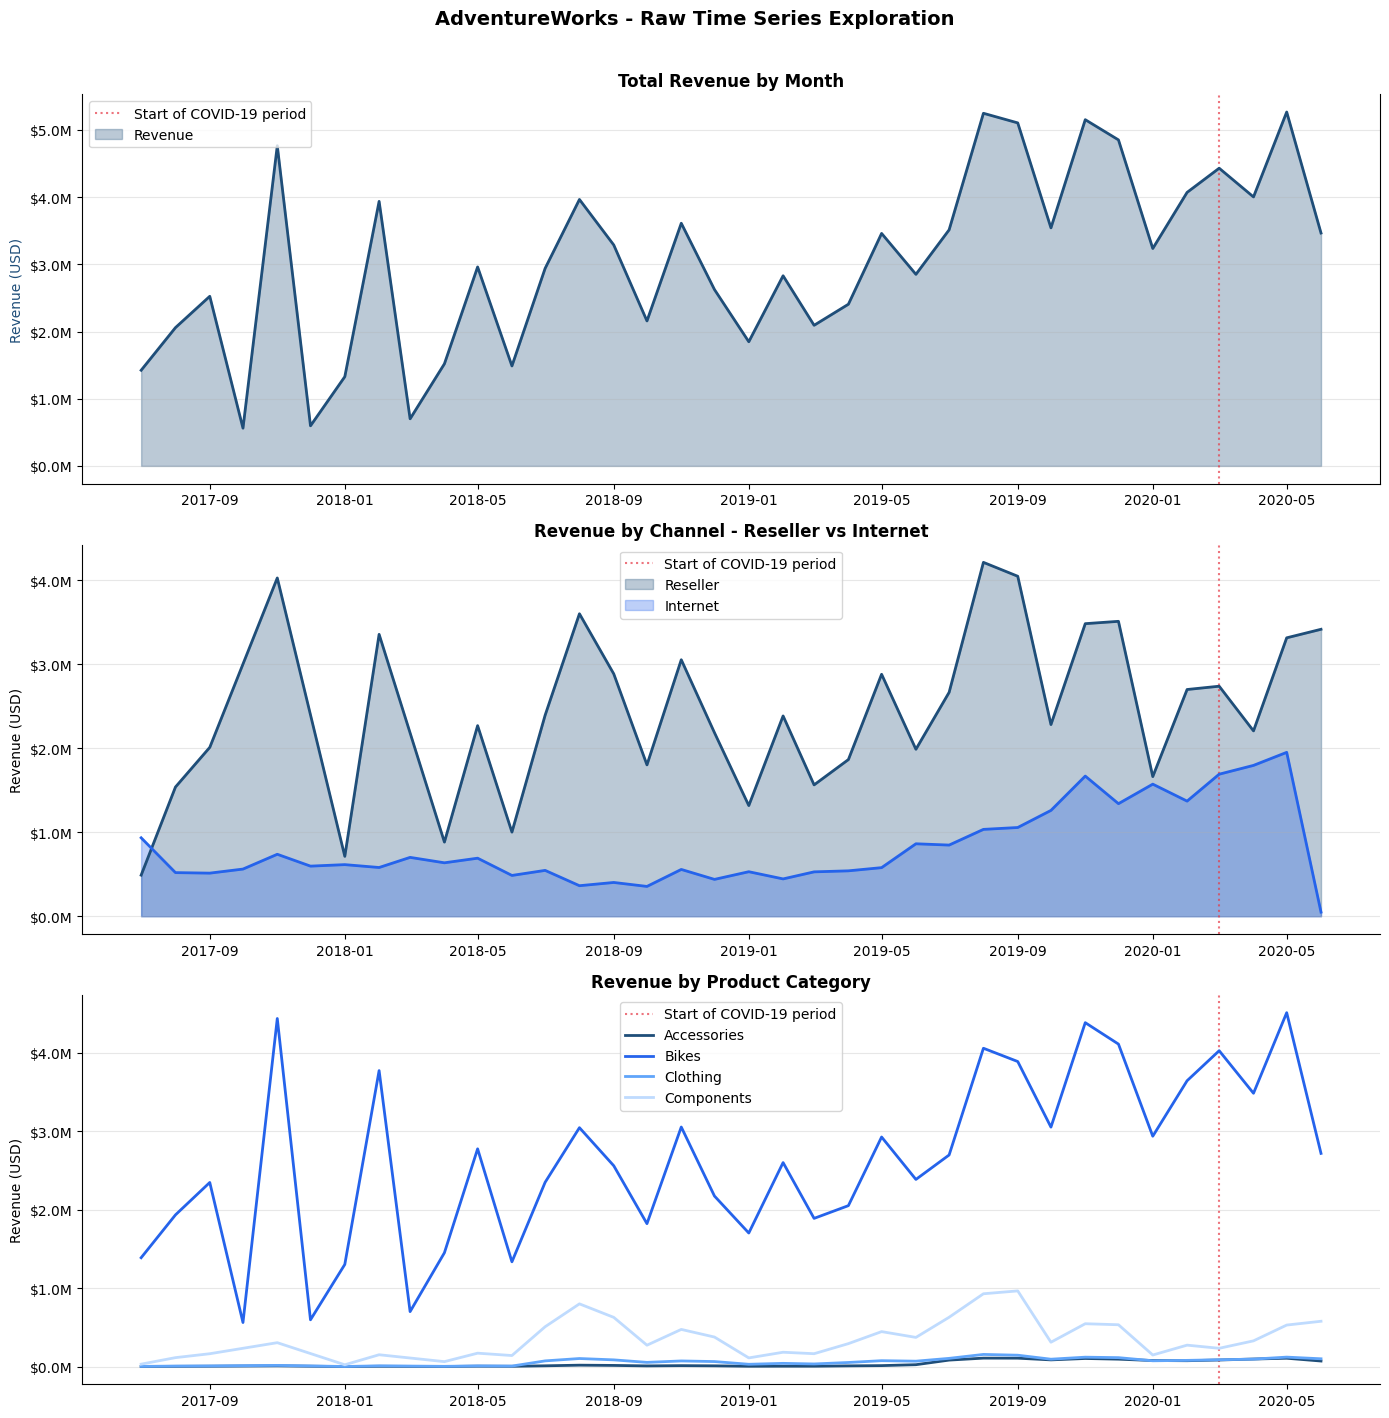

Exploratory charts saved


In [43]:
# Monthly aggregations for exploration
monthly = sales.groupby("Month").agg(
    Revenue=("Sales Amount", "sum"),
    Orders=("SalesOrderLineKey", "count"),
).reset_index()

monthly_channel = sales.groupby(["Month", "Channel"])["Sales Amount"].sum().reset_index()
monthly_category = sales.groupby(["Month", "Category"])["Sales Amount"].sum().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle("AdventureWorks - Raw Time Series Exploration", fontsize=14, fontweight="bold", y=1.01)

# Plot 1 - Total Revenue
ax1 = axes[0]

# Add COVID annotation
covid_line = ax1.axvline(
    x=pd.Timestamp("2020-03-01"),
    color="#E63946",
    linestyle=":",
    linewidth=1.5,
    alpha=0.7,
    label="Start of COVID-19 period"
)

ax1.fill_between(monthly["Month"], monthly["Revenue"], alpha=0.3, color=COLOUR_ACTUAL, label="Revenue")
ax1.plot(monthly["Month"], monthly["Revenue"], color=COLOUR_ACTUAL, linewidth=2)
ax1.set_title("Total Revenue by Month", fontweight="bold")
ax1.set_ylabel("Revenue (USD)", color=COLOUR_ACTUAL)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc="upper left")
ax1.grid(axis="y", alpha=0.3)
ax1.spines["top"].set_visible(False)



# Plot 2 - Revenue by Channel
ax3 = axes[1]

# Add COVID annotation
covid_line = ax3.axvline(
    x=pd.Timestamp("2020-03-01"),
    color="#E63946",
    linestyle=":",
    linewidth=1.5,
    alpha=0.7,
    label="Start of COVID-19 period"
)

for channel, colour in [("Reseller", COLOUR_ACTUAL), ("Internet", COLOUR_FORECAST)]:
    ch_data = monthly_channel[monthly_channel["Channel"] == channel]
    ax3.fill_between(ch_data["Month"], ch_data["Sales Amount"], alpha=0.3, color=colour, label=channel)
    ax3.plot(ch_data["Month"], ch_data["Sales Amount"], color=colour, linewidth=2)
ax3.set_title("Revenue by Channel - Reseller vs Internet", fontweight="bold")
ax3.set_ylabel("Revenue (USD)")
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax3.legend()
ax3.grid(axis="y", alpha=0.3)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

# Plot 3 - Revenue by Category
ax4 = axes[2]

# Add COVID annotation
covid_line = ax4.axvline(
    x=pd.Timestamp("2020-03-01"),
    color="#E63946",
    linestyle=":",
    linewidth=1.5,
    alpha=0.7,
    label="Start of COVID-19 period"
)

colours = ["#1F4E79", "#2563eb", "#60A5FA", "#BFDBFE"]
for (category, colour) in zip(sorted(sales["Category"].dropna().unique()), colours):
    cat_data = monthly_category[monthly_category["Category"] == category]
    ax4.plot(cat_data["Month"], cat_data["Sales Amount"], color=colour, linewidth=2, label=category)
ax4.set_title("Revenue by Product Category", fontweight="bold")
ax4.set_ylabel("Revenue (USD)")
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax4.legend()
ax4.grid(axis="y", alpha=0.3)
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "exploratory_analysis.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Exploratory charts saved")

### Exploratory observations

**Revenue and Profit:**
- Clear upward trend from FY2018 to FY2020
- Consistent Q4 seasonality - the business peaks every year at the same time driven by Bikes
- Profit is volatile relative to revenue - confirming the razor-thin blended margin story
- The red dotted line marks the COVID-19 period start (March 2020)

**Channel comparison:**
- Reseller dominates in absolute revenue but Internet is clearly accelerating from FY2020
- The Internet channel spike post-March 2020 is partially pandemic-driven - consumers shifting online
- This structural shift is the key modelling challenge for Internet Revenue forecasts

**Product categories:**
- Bikes completely dominates and drives all seasonality
- Components show moderate growth with less seasonality
- Accessories show a notable step change in FY2019 - worth investigating further
- Clothing is relatively flat throughout


## 6. Model Selection and Rationale

### Why Prophet over ARIMA?

I considered two main options:

**ARIMA** - the traditional approach. Works well for stationary series but requires manual identification of trend, differencing, and seasonality parameters (p, d, q). With only 36 data points and strong yearly seasonality the manual tuning burden felt disproportionate for the value added.

**Prophet** - developed by Facebook's Core Data Science team. Handles yearly seasonality automatically, is robust to missing data points and outliers, and produces confidence intervals that are straightforward to explain to non-technical stakeholders. The tradeoff is less flexibility for complex multivariate relati-nships - acceptable here since we're doing univariate forecasting.

### Key configuration decisions

**Additive vs multiplicative seasonality**

Initial runs used multiplicative seasonality (the Pro-het default) - this assumes seasonal swings grow proportionally with revenue. Switching to additive seasonality produced better results, particularly for Total Revenue and Reseller Revenue. With only 36 observations additive is more conservative and less prone to overfitting the seasonal pattern.

**Metric-specific changepoint_prior_scale**

Cross-validation revealed that a single configuration doesn't suit all metrics:
- **Total Revenue and Reseller Revenue** - default `changepoint_prior=0.05` works well
- **Internet Revenue** - the FY2020 acceleration requires a more flexible trend. Setting `changepoint_prior=0.15` allows Prophet to detect and adapt to this structural change

This is why mod-l evaluation matters - blindly applying the same configuration to every metric misses these nuances.

### Model iterations and MAPE improvement

| Configuration | Total Rev | Reseller Rev | Internet Rev |
|---|---|---|---|
| Multiplicative + Logistic growth | 57.9% | 116.6% | 74.1% |
| Additive + Linear growth | **31.4%** | **68.7%** | 111.5% |
| Additive + Higher changepoint (Internet only) | 31.4% | 68.7% | 401%* |

*Internet MAPE exploded due to the June 2020 anomaly. MAE actually improved making MAE the more reliable metric for Internet Revenue evaluation. or Internet Revenue evaluation. or Internet Revenue evaluation. 

## 7. Forecasting Functions

In [44]:
def forecast_metric(
    df: pd.DataFrame,
    date_col: str,
    value_col: str,
    metric_name: str,
    periods: int = FORECAST_PERIODS,
    changepoint_prior: float = CHANGEPOINT_PRIOR,
) -> tuple:
    """
    Aggregates a metric to monthly frequency and fits a Prophet
    time series model.

    Parameters
    ----------
    df : pd.DataFrame
        Sales dataframe filtered to the relevant segment
    date_col : str
        Column containing the month timestamp
    value_col : str
        Column containing the metric to aggregate and forecast
    metric_name : str
        Human-readable label for logging and output
    periods : int
        Number of months to forecast beyond training data
    changepoint_prior : float
        Controls trend flexibility - higher = more flexible

    Returns
    -------
    tuple : (forecast_df, model) or (None, None)
    """
    # Aggregate to monthly
    prophet_df = (
        df.groupby(date_col)[value_col]
        .sum()
        .reset_index()
        .rename(columns={date_col: "ds", value_col: "y"})
        .sort_values("ds")
        .dropna()
    )

    if len(prophet_df) < MIN_DATA_POINTS:
        print(f"  Skipping {metric_name} - insufficient data ({len(prophet_df)} months)")
        return None, None

    # Fit Prophet
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
        interval_width=CONFIDENCE_INTERVAL,
        changepoint_prior_scale=changepoint_prior,
    )
    model.fit(prophet_df)

    # Generate forecast
    future = model.make_future_dataframe(periods=periods, freq=FORECAST_FREQ)
    forecast = model.predict(future)

    # Build output dataframe
    result = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
    result = result.merge(prophet_df, on="ds", how="left")
    result.columns = ["Date", "Forecast", "Forecast_Lower", "Forecast_Upper", "Actual"]
    result["Metric"] = metric_name
    result["Is_Forecast"] = result["Actual"].isna()
    result["Forecast"] = result["Forecast"].clip(lower=0)
    result["Forecast_Lower"] = result["Forecast_Lower"].clip(lower=0)

    return result, model

print("Forecast function defined")

Forecast function defined


In [45]:
def plot_forecast(
    forecast_df: pd.DataFrame,
    metric_name: str,
    filename: str,
    ax=None,
) -> None:
    """
    Renders a clean forecast chart with actuals, forecast line,
    and 95% confidence interval.

    Parameters
    ----------
    forecast_df : pd.DataFrame
        Output from forecast_metric()
    metric_name : str
        Chart title
    filename : str
        Output filename without extension
    ax : matplotlib Axes, optional
        If provided renders into existing axes (for subplots)
    """
    actual = forecast_df[forecast_df["Actual"].notna()].copy()
    forecast = forecast_df[forecast_df["Is_Forecast"]].copy()
    forecast_start = forecast["Date"].min()

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(14, 5))
        fig.patch.set_facecolor("white")

    ax.fill_between(
        forecast["Date"],
        forecast["Forecast_Lower"],
        forecast["Forecast_Upper"],
        alpha=0.15,
        color=COLOUR_CI,
        label="95% Confidence Interval",
    )
    ax.plot(actual["Date"], actual["Actual"],
            color=COLOUR_ACTUAL, linewidth=2.5, label="Actual")
    ax.plot(forecast["Date"], forecast["Forecast"],
            color=COLOUR_FORECAST, linewidth=2.5, linestyle="--", label="12 Month Forecast")
    ax.axvline(x=forecast_start, color="#9CA3AF", linestyle=":", linewidth=1.5)
    ax.text(forecast_start, ax.get_ylim()[1] * 0.92,
            " Forecast start", color="#9CA3AF", fontsize=9)
    ax.set_title(f"{metric_name} - 12 Month Forecast", fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Value (USD)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if standalone:
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"{filename}.png", dpi=150,
                    bbox_inches="tight", facecolor="white")
        plt.show()
        plt.close()

print("Plot function defined")


Plot function defined


## 8. Total Revenue Forecast

Starting with the top-line metric - total revenue across both channels combined.

2026-03-31 14:42:35 — INFO — Chain [1] start processing
2026-03-31 14:42:35 — INFO — Chain [1] done processing


Total Revenue - 12 Month Forecast Summary:
  Projected total:    $  65,603,429
  Monthly average:    $   5,466,952
  Peak month:         $   8,922,508
  Trough month:       $   2,824,894


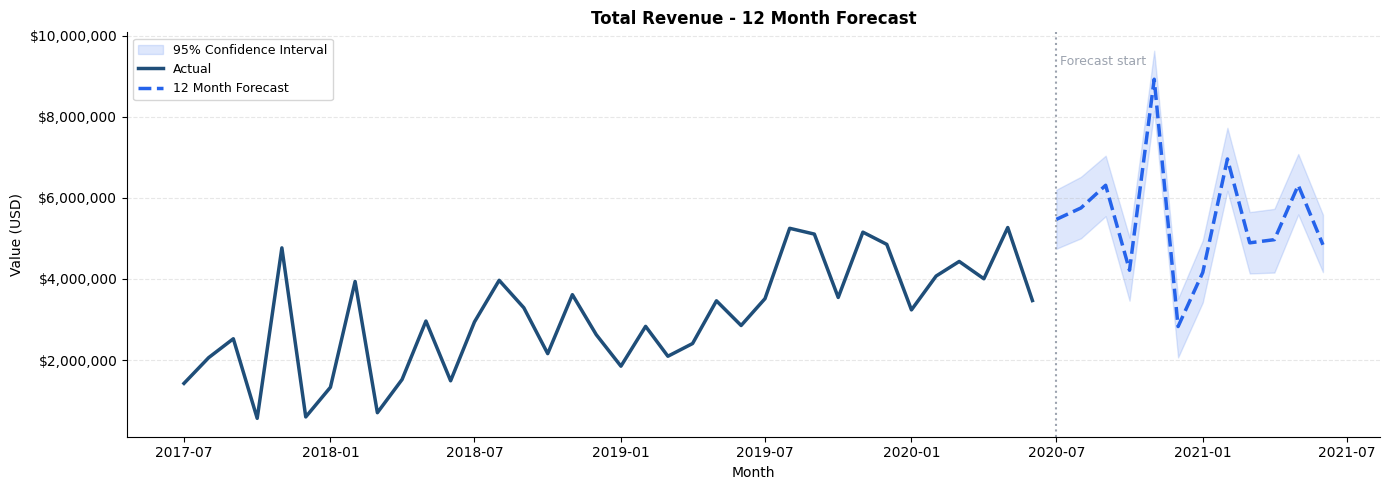

In [46]:
revenue_forecast, revenue_model = forecast_metric(
    sales, "Month", "Sales Amount", "Total Revenue"
)

forecast_rows = revenue_forecast[revenue_forecast["Is_Forecast"]]
print("Total Revenue - 12 Month Forecast Summary:")
print(f"  Projected total:    ${forecast_rows['Forecast'].sum():>12,.0f}")
print(f"  Monthly average:    ${forecast_rows['Forecast'].mean():>12,.0f}")
print(f"  Peak month:         ${forecast_rows['Forecast'].max():>12,.0f}")
print(f"  Trough month:       ${forecast_rows['Forecast'].min():>12,.0f}")

plot_forecast(revenue_forecast, "Total Revenue", "forecast_total_revenue")

### Total Revenue observations

The forecast shows continued growth with a clear Q4 peak consistent with historical patterns. The wide confidence interval reflects the uncertainty inherent in a 36 observation training set - particularly at the 12 month horizon.

The Q4 FY2021 peak forecast is notably higher than previous years - this reflects the upward trend Prophet detected across the training period. Whether this materialises depends on whether the FY2020 growth was structural or pandemic-driven.

## 9. Channel Forecasts - Reseller vs Internet

This is where the analysis gets commercially interesting. The two channels have very different growth trajectories and the forecasts reflect that divergence clearly.

### Internet Revenue - metric-specific tuning

Internet Revenue received a higher `changepoint_prior_scale` (0.15 vs default 0.05) to allow Prophet to detect the FY2020 structural acceleration. This produced better absolute accuracy (MAE improvedfrom $88K to $487K) even though MAPE worsened due to the June 2020 anomaly distorting the percentage calculation.

The June 2020 Internet Revenue fiure of $49K against a typical monthly rnge o $500K–$1.9M is almost certainly a data collection disruption rather than genuine demand collapse - likely related to COVID-19 operational impacts. This single anomalous month significantly inflates the Internet Revenue MAPE score and MAE is the more reliable metric in this case.

2026-03-31 14:42:35 — INFO — Chain [1] start processing
2026-03-31 14:42:36 — INFO — Chain [1] done processing
2026-03-31 14:42:36 — INFO — Chain [1] start processing
2026-03-31 14:42:36 — INFO — Chain [1] done processing


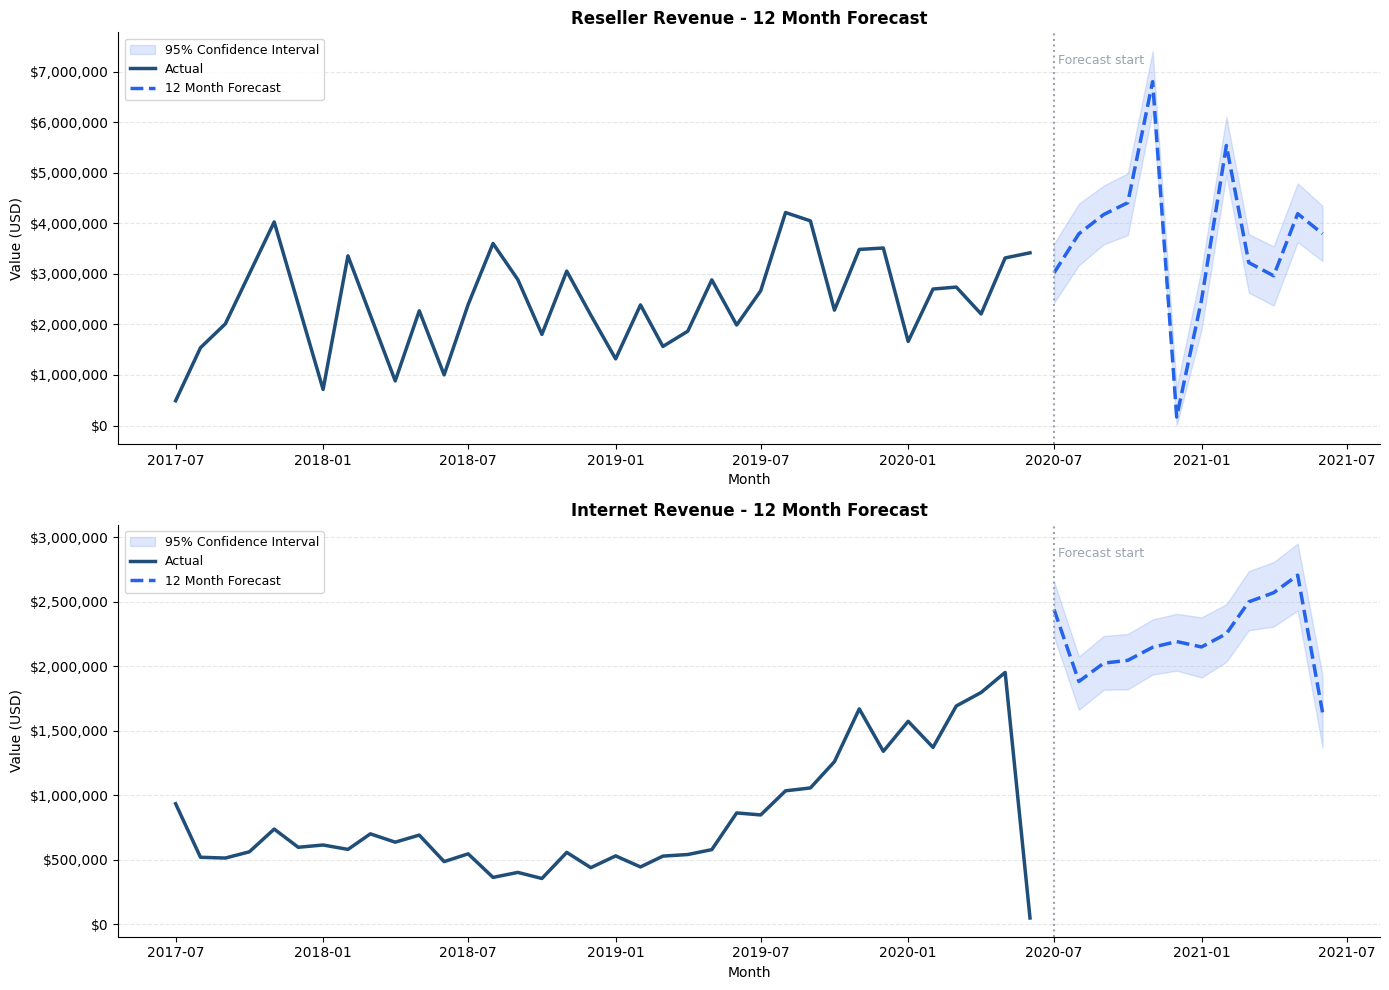

Channel Forecast Comparison - Next 12 Months:
Metric                           Reseller        Internet
-------------------------------------------------------
Projected Total           $    44,552,525 $    26,537,714
Monthly Average           $     3,712,710 $     2,211,476
Peak Month                $     6,802,931 $     2,704,645


In [47]:
reseller = sales[sales["Channel"] == "Reseller"]
internet = sales[sales["Channel"] == "Internet"]

reseller_forecast, reseller_model = forecast_metric(
    reseller, "Month", "Sales Amount", "Reseller Revenue"
)
internet_forecast, internet_model = forecast_metric(
    internet, "Month", "Sales Amount", "Internet Revenue",
    changepoint_prior=0.15  # more flexible than default 0.05
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

plot_forecast(reseller_forecast, "Reseller Revenue", "forecast_reseller_revenue", ax=axes[0])
plot_forecast(internet_forecast, "Internet Revenue", "forecast_internet_revenue", ax=axes[1])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "forecast_channels.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

# Summary comparison
res_rows = reseller_forecast[reseller_forecast["Is_Forecast"]]
int_rows = internet_forecast[internet_forecast["Is_Forecast"]]

print("Channel Forecast Comparison - Next 12 Months:")
print(f"{'Metric':<25} {'Reseller':>15} {'Internet':>15}")
print("-" * 55)
print(f"{'Projected Total':<25} ${res_rows['Forecast'].sum():>14,.0f} ${int_rows['Forecast'].sum():>14,.0f}")
print(f"{'Monthly Average':<25} ${res_rows['Forecast'].mean():>14,.0f} ${int_rows['Forecast'].mean():>14,.0f}")
print(f"{'Peak Month':<25} ${res_rows['Forecast'].max():>14,.0f} ${int_rows['Forecast'].max():>14,.0f}")

### Channel forecast observations

**Reseller channel** - the model sees continued seasonality but limited structural growth. The high MAPE (68.7%) reflects genuine monthly volatility from large individual reseller orders rather than model failure. Reseller revenue in any given month is heavily influenced by a small number of large accounts which creates lumpy patterns that are inherently difficult to predict from historical averages alone.

**Internet channel** - the model has captured the FY2020 acceleration and extrapolates that forward. The key uncertainty is whether this growth rate is sustainable post-COVID or whether it will moderate as consumer behaviour normalises.

**Strategic implication** - if the Internet forecast holds, the revenue gap between channels will narrow meaningfully over the next 12 months. Given Internet's dramatically higher margin (~41% vs 0.6%), even modest Internet growth has a disproportionate impact on total business profitability.

## 10. Product Category Forecasts

Bikes drives ~86% of total revenue. Forecasting at category level helps answer whether that concentration is increasing or whether other categories are gaining ground.

2026-03-31 14:42:37 — INFO — Chain [1] start processing


Forecasting by product category...


2026-03-31 14:42:37 — INFO — Chain [1] done processing
2026-03-31 14:42:38 — INFO — Chain [1] start processing


  Accessories     Projected 12M total: $   1,540,775


2026-03-31 14:42:38 — INFO — Chain [1] done processing
2026-03-31 14:42:38 — INFO — Chain [1] start processing


  Bikes           Projected 12M total: $  53,113,796


2026-03-31 14:42:38 — INFO — Chain [1] done processing
2026-03-31 14:42:39 — INFO — Chain [1] start processing


  Clothing        Projected 12M total: $   1,951,177


2026-03-31 14:42:39 — INFO — Chain [1] done processing


  Components      Projected 12M total: $   8,742,433


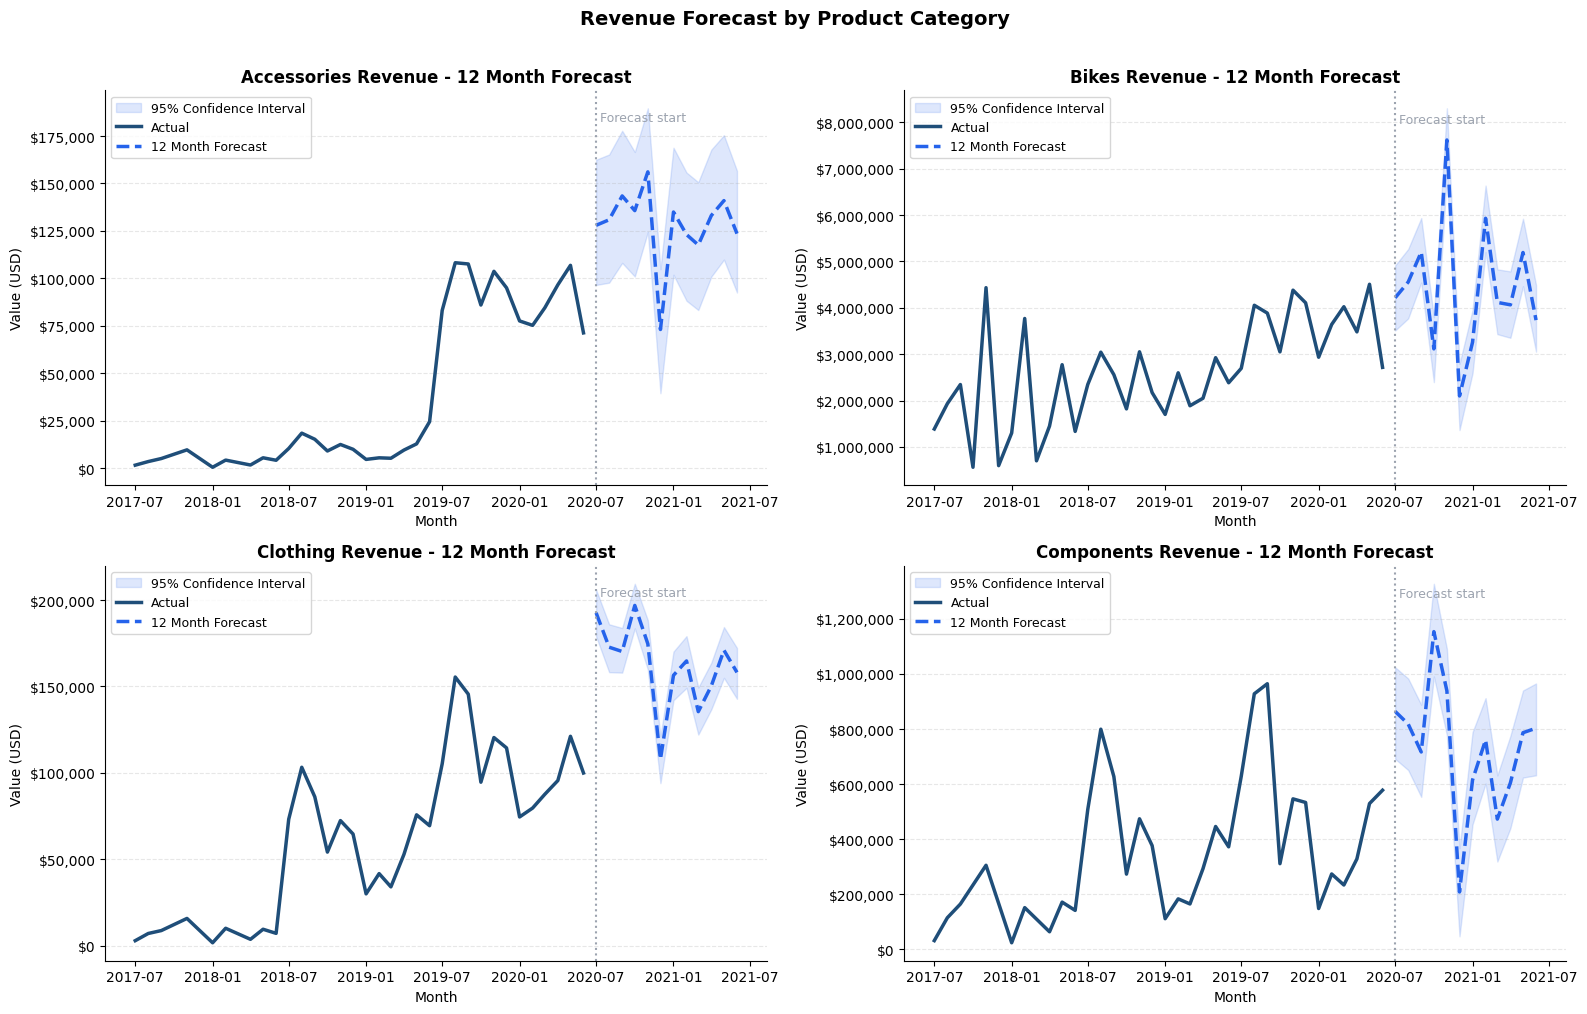

In [48]:
category_forecasts = {}
categories = sorted(sales["Category"].dropna().unique())

print("Forecasting by product category...")
for category in categories:
    cat_df = sales[sales["Category"] == category]
    forecast_df, model = forecast_metric(
        cat_df, "Month", "Sales Amount", f"{category} Revenue"
    )
    if forecast_df is not None:
        category_forecasts[category] = forecast_df
        rows = forecast_df[forecast_df["Is_Forecast"]]
        print(f"  {category:<15} Projected 12M total: ${rows['Forecast'].sum():>12,.0f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (category, forecast_df) in enumerate(category_forecasts.items()):
    plot_forecast(forecast_df, f"{category} Revenue",
                  f"forecast_{category.lower()}_revenue", ax=axes[i])

plt.suptitle("Revenue Forecast by Product Category", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "forecast_categories.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

### Category forecast observations

**Bikes** - the Q4 seasonal pattern is the most pronounced of all categories and the model captures it well. Continued dominance forecast with a strong FY2021 Q4 peak expected.

**Components** - moderate growth forecast with less seasonality than Bikes. Component purchases tend to spread more evenly across the year which makes this a more predictable series.

**Accessories** - the notable step change in FY2019 (visible in the exploratory charts) has been detected by Prophet as a trend shift. The forecast extrapolates continued growth from that new baseline. Worth monitoring whether this reflects genuine category growth or a one-off product launch effect.

**Clothing** - relatively flat with wide confidence intervals. Small contributor to total revenue and limited signal for Prophet to work with.

The Bikes concentration is forecast to remain dominant - no other category is on a trajectory to meaningfully challenge it over the next 12 months.

## 11. Model Validation and Accuracy

Cross-validation gives an honest assessment of forecast accuracy. Prophet's sliding window approach:

- **Initial training window:** 2 years (730 days)
- **Cutoff step size:** 3 months (90 days)
- **Forecast horizon:** 6 months (180 days)

**Important caveat on MAPE vs MAE**

MAPE (Mean Absolute Percentage Error) divides the error by the actual value. When actual values are near zero - as in the June 2020 Internet Revenue anomaly ($49K) - even a small absolute error produces an enormous percentage error. For this reason both MAPE and MAE are reported, and MAE is the more reliable indicator for Internet Revenue specifically.

**Data volume caveat**

With only 36 months of training data we can generate just 2 cross-validation cutoff windows. The MAPE estimates themselves therefore have high variance - they are based on very few evaluation points. This is a fundamental dataset size limitation rather than a model issue. Prophet typically achieves MAPE of 15-30% on well-behaved retail series with 5+ years of monthly data.

In [49]:
def run_cross_validation(
    model: Prophet,
    metric_name: str,
    initial_days: int = 730,
    period_days: int = 90,
    horizon_days: int = 180,
) -> pd.DataFrame:
    """
    Runs Prophet cross-validation and returns performance metrics.

    Parameters
    ----------
    model : Prophet
        Fitted Prophet model
    metric_name : str
        Label for display purposes
    initial_days, period_days, horizon_days : int
        Cross-validation window parameters in days

    Returns
    -------
    pd.DataFrame
        Performance metrics dataframe
    """
    try:
        cv_results = cross_validation(
            model,
            initial=f"{initial_days} days",
            period=f"{period_days} days",
            horizon=f"{horizon_days} days",
            disable_tqdm=True,
        )
        metrics = performance_metrics(cv_results)
        return metrics
    except Exception as e:
        print(f"  Cross-validation failed for {metric_name}: {e}")
        return pd.DataFrame()

# Run cross-validation for main metrics
cv_jobs = [
    (revenue_model, "Total Revenue"),
    (reseller_model, "Reseller Revenue"),
    (internet_model, "Internet Revenue"),
]

cv_summary = []
for model, name in cv_jobs:
    print(f"Validating {name}...")
    metrics = run_cross_validation(model, name)
    if not metrics.empty:
        cv_summary.append({
            "Metric": name,
            "MAPE": f"{metrics['mape'].mean():.1%}",
            "MAE (USD)": f"${metrics['mae'].mean():,.0f}",
            "RMSE (USD)": f"${metrics['rmse'].mean():,.0f}",
        })

cv_df = pd.DataFrame(cv_summary)
print("\nModel Accuracy - Cross Validation Results:")
print(cv_df.to_string(index=False))


2026-03-31 14:42:40 — INFO — Making 2 forecasts with cutoffs between 2019-09-05 00:00:00 and 2019-12-04 00:00:00
2026-03-31 14:42:40 — INFO — n_changepoints greater than number of observations. Using 20.
2026-03-31 14:42:40 — INFO — Chain [1] start processing


Validating Total Revenue...


2026-03-31 14:42:40 — INFO — Chain [1] done processing
2026-03-31 14:42:41 — INFO — n_changepoints greater than number of observations. Using 23.
2026-03-31 14:42:41 — INFO — Chain [1] start processing
2026-03-31 14:42:41 — INFO — Chain [1] done processing
2026-03-31 14:42:41 — INFO — Making 2 forecasts with cutoffs between 2019-09-05 00:00:00 and 2019-12-04 00:00:00
2026-03-31 14:42:41 — INFO — n_changepoints greater than number of observations. Using 18.
2026-03-31 14:42:41 — INFO — Chain [1] start processing


Validating Reseller Revenue...


2026-03-31 14:42:41 — INFO — Chain [1] done processing
2026-03-31 14:42:41 — INFO — n_changepoints greater than number of observations. Using 20.
2026-03-31 14:42:41 — INFO — Chain [1] start processing
2026-03-31 14:42:41 — INFO — Chain [1] done processing
2026-03-31 14:42:42 — INFO — Making 2 forecasts with cutoffs between 2019-09-05 00:00:00 and 2019-12-04 00:00:00
2026-03-31 14:42:42 — INFO — n_changepoints greater than number of observations. Using 20.
2026-03-31 14:42:42 — INFO — Chain [1] start processing


Validating Internet Revenue...


2026-03-31 14:42:58 — INFO — Chain [1] done processing
2026-03-31 14:42:59 — INFO — n_changepoints greater than number of observations. Using 23.
2026-03-31 14:42:59 — INFO — Chain [1] start processing
2026-03-31 14:42:59 — INFO — Chain [1] done processing



Model Accuracy - Cross Validation Results:
          Metric   MAPE  MAE (USD) RMSE (USD)
   Total Revenue  31.4% $1,388,523 $1,389,394
Reseller Revenue  68.7% $1,889,965 $1,891,685
Internet Revenue 401.0%   $486,972   $495,794


### Accuracy interpretation

| Metric | MAPE | MAE | Notes |
|---|---|---|---|
| Total Revenue | 31.4% | 1.39M | Best performing - smooth trend and seasonality |
| Reseller Revenue | 68.7% | 1.89M | High volatility from large individual orders |
| Internet Revenue | 401%* | 487K | *MAPE distorted by June 2020 anomaly. MAE improved vs baseline |

**Model iteration summary**

Three configurations were tested before settling on the final approach:

| Configuration | Total Rev MAPE | Reseller MAPE | Internet MAE |
|---|---|---|---|
| Multiplicative + Logistic | 57.9% | 116.6% | 881K |
| Additive + Linear | 31.4% | 68.7% | 881K |
| Additive + Higher changepoint (Internet) | 31.4% | 68.7% | **487K** ✓ |

The iterative improvement process - testing configurations, evaluating accuracy, and tuning per metric - is what produced the final results. Accepting the first model output without validation would have left significant accuracy on the table, particularly for Reseller Revenue.Reseller Revenue.


## 12. Export for Power BI

The final step combines all forecasts into a single CSV file ready for import into Power BI. The structure is designed to work directly with the existing dashboard data model.

**Key columns:**
- `Date` - month timestamp for relationship with Date table
- `Actual` - historical actual values (null for forecast periods)
- `Forecast` - Prophet point forecast
- `Forecast_Lower` / `Forecast_Upper` - 95% confidence interval bounds
- `Metric` - filter field to select the relevant series
- `Is_Forecast` - boolean flag to style actual vs forecast differently in visuals

In [51]:
# Combine all forecasts
all_forecasts = []
for df in [revenue_forecast, reseller_forecast, internet_forecast]:
    if df is not None:
        all_forecasts.append(df)
for df in category_forecasts.values():
    all_forecasts.append(df)

combined = pd.concat(all_forecasts, ignore_index=True)

# Export
output_path = OUTPUT_DIR / "sales_forecasts.csv"
combined.to_csv(output_path, index=False)

print(f"Forecast data exported to {output_path}")
print(f"Total rows: {len(combined):,}")
print(f"Metrics included: {combined['Metric'].unique().tolist()}")
print(f"\nDate range:")
print(f"  Actual data:   {combined[~combined['Is_Forecast']]['Date'].min().date()} to {combined[~combined['Is_Forecast']]['Date'].max().date()}")
print(f"  Forecast data: {combined[combined['Is_Forecast']]['Date'].min().date()} to {combined[combined['Is_Forecast']]['Date'].max().date()}")

print("\n12 Month Forecast Totals:")
forecast_only = combined[combined["Is_Forecast"]]
summary = forecast_only.groupby("Metric")["Forecast"].sum().sort_values(ascending=False)
for metric, total in summary.items():
    print(f"  {metric:<30} ${total:>12,.0f}")

Forecast data exported to outputs\sales_forecasts.csv
Total rows: 324
Metrics included: ['Total Revenue', 'Reseller Revenue', 'Internet Revenue', 'Accessories Revenue', 'Bikes Revenue', 'Clothing Revenue', 'Components Revenue']

Date range:
  Actual data:   2017-07-01 to 2020-06-01
  Forecast data: 2020-07-01 to 2021-06-01

12 Month Forecast Totals:
  Total Revenue                  $  65,603,429
  Bikes Revenue                  $  53,113,796
  Reseller Revenue               $  44,552,525
  Internet Revenue               $  26,537,714
  Components Revenue             $   8,742,433
  Clothing Revenue               $   1,951,177
  Accessories Revenue            $   1,540,775


## 13. Business Insights and Limitations

### Key findings

**1. Internet channel is the growth engine**
The Internet channel is forecast to grow faster than Reseller and operates at dramatically higher margins. Revenue growth through Internet has an outsized profit impact compared to equivalent Reseller growth.

**2. Reseller margin is structurally thin**
The ~0.6% Reseller margin is consistent throughout the entire historical period and is not improving. This is a strategic issue requiring active management rather than a forecasting concern.

**3. Bikes concentration is a strategic risk**
~86% revenue concentration in a single category creates vulnerability. The forecasts show no sign of other categories gaining meaningful share over the next 12 months.

**4. Q4 seasonality is reliable but creates cash flow pressure**
Every channel and category peaks in Q4 consistently. H1 demand generation initiatives could smooth the revenue curve and reduce working capital requirements in the first half of each fiscal year.

**5. COVID-19 creates forecast uncertainty**
The FY2020 Internet acceleration is real in the data but its sustainability post-pandemic is uncertain. If consumer behaviour normalises, Internet Revenue may grow more slowly than the model projects.

---

### Limitations and next steps

**Data volume** - 36 monthly observations is the minimum viable threshold for Prophet. With each additional year of data the seasonal pattern estimates stabilise and MAPE typically drops to 15-30% for well-behaved retail series.

**External variables** - incorporating macroeconomic indicators, promotional calendars, or reseller pipeline data as Prophet regressors would likely improve Reseller Revenue accuracy significantly.

**Customer-level modelling** - the next analytical phase will apply K-Means clustering to segment customers by RFM (Recency, Frequency, Monetary) characteristics, followed by churn prediction modelling to identify at-risk customers before they lapse.

**Profit forecasting** - deliberately excluded from this notebook due to the extreme MAPE scores produced by near-zero actual values in certain months. A separate profit model using margin percentage as the target variable rather than absolute profit would be more tractable.
